# **Car Damage Assessment & Detection**


## Problem Statement

Car damage assessment from images is an important application in automotive inspection and insurance-related workflows. This project develops a computer-vision-based machine learning system to identify different types of car damage from images and assess the visible extent of the damage.


## Objective

The primary objective is to develop and deploy a classical machine learning system that:

1. Preprocesses car-damage images using OpenCV.
2. Extracts meaningful visual features using HOG and LBP descriptors.
3. Applies PCA to reduce the dimensionality of the feature space.
4. Trains and evaluates a One-vs-Rest Linear SVM for multi-label damage classification.
5. Estimates visible damage severity extent using CarDD annotations.


## Dataset Overview

### Dataset

**CarDD: A New Dataset for Vision-Based Car Damage Detection**

### Dataset Characteristics

- **Images:** 4,000 high-resolution car-damage images
- **Damage Instances:** 9,000+
- **Damage Categories:** 6
- **Image Type:** Car damage images
- **Annotations:** Bounding boxes and pixel-level segmentation annotations
- **Dataset Format:** COCO-style annotations

The dataset contains six major categories of car damage:

- Dent
- Scratch
- Crack
- Glass Shatter
- Lamp Broken
- Tire Flat

The annotations provide information about the location and extent of visible damage, which will also be used later in the project for damage-extent and severity analysis.

### Dataset Source

Official CarDD Dataset:

https://cardd-ustc.github.io/

## 1. Load the Dataset


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
zip_path = "/content/drive/MyDrive/CarDD/CarDD_COCO.zip"
extract_path = "/content/CarDD"

In [4]:
import zipfile
import os

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("CarDD_COCO extracted successfully.")

CarDD_COCO extracted successfully.


In [5]:
data_path = "/content/CarDD/CarDD_COCO"
print(os.listdir(data_path))

['annotations', 'val2017', 'test2017', 'train2017']


In [6]:
annotations_path = os.path.join(
    data_path,
    "annotations"
)

train_path = os.path.join(
    data_path,
    "train2017"
)

val_path = os.path.join(
    data_path,
    "val2017"
)

test_path = os.path.join(
    data_path,
    "test2017"
)

In [7]:
print("Dataset path:", data_path)

print("\nContents:")
print(os.listdir(data_path))

print("\nNumber of training images:",
      len(os.listdir(train_path)))

print("Number of validation images:",
      len(os.listdir(val_path)))

print("Number of test images:",
      len(os.listdir(test_path)))

Dataset path: /content/CarDD/CarDD_COCO

Contents:
['annotations', 'val2017', 'test2017', 'train2017']

Number of training images: 2816
Number of validation images: 810
Number of test images: 374


## 2. Dataset Inspection


In [8]:
print("Annotation files:")
print(os.listdir(annotations_path))

Annotation files:
['instances_test2017.json', 'instances_val2017.json', 'instances_train2017.json', 'image_info.xlsx']


In [9]:
import json
train_annotation_path = os.path.join(
    annotations_path,
    "instances_train2017.json"
)

with open(train_annotation_path, "r") as file:
    train_annotations = json.load(file)

print("Annotation keys:")
print(train_annotations.keys())

Annotation keys:
dict_keys(['licenses', 'info', 'categories', 'images', 'annotations'])


In [10]:
print("Number of categories:", len(train_annotations["categories"]))
print("\nCategories:")
print(train_annotations["categories"])

print("\nNumber of images:", len(train_annotations["images"]))
print("Number of annotations:", len(train_annotations["annotations"]))

print("\nFirst image record:")
print(train_annotations["images"][0])

print("\nFirst annotation record:")
print(train_annotations["annotations"][0])

Number of categories: 6

Categories:
[{'id': 1, 'name': 'dent'}, {'id': 2, 'name': 'scratch'}, {'id': 3, 'name': 'crack'}, {'id': 4, 'name': 'glass shatter'}, {'id': 5, 'name': 'lamp broken'}, {'id': 6, 'name': 'tire flat'}]

Number of images: 2816
Number of annotations: 6211

First image record:
{'id': 1, 'width': 1000, 'height': 750, 'file_name': '000001.jpg', 'license': 0}

First annotation record:
{'id': 1, 'image_id': 1, 'category_id': 2, 'segmentation': [[233.35, 46.65, 217.25, 58.24, 210.82, 65.97, 204.38, 78.2, 197.3, 93.0, 192.15, 104.59, 187.0, 112.96, 180.56, 123.91, 174.12, 135.49, 169.61, 144.51, 167.04, 154.16, 167.04, 165.11, 175.41, 170.9, 185.71, 171.55, 196.01, 167.68, 205.02, 161.24, 214.03, 154.81, 224.33, 148.37, 233.99, 141.93, 244.29, 134.21, 256.52, 128.41, 267.47, 125.19, 277.77, 122.62, 288.71, 119.4, 298.37, 116.82, 310.6, 113.61, 322.83, 109.1, 333.13, 105.88, 344.08, 103.95, 355.02, 101.37, 366.61, 97.51, 369.83, 87.21, 364.68, 78.84, 352.45, 69.18, 341.5, 

In [11]:
import numpy as np
import pandas as pd
image_info_path = os.path.join(
    annotations_path,
    "image_info.xlsx"
)

image_info = pd.read_excel(image_info_path)

print("Image information shape:", image_info.shape)

print("\nColumns:")
print(image_info.columns.tolist())

print("\nFirst five rows:")
display(image_info.head())

Image information shape: (4000, 10)

Columns:
['id', 'file_name', 'width', 'height', 'file_size (KB)', '#instances', '#categories', 'shooting angle', 'complete or partial ', 'color']

First five rows:


,id,file_name,width,height,file_size (KB),#instances,#categories,shooting angle,complete or partial,color
0,1,000001.jpg,1000,750,1114,2,2,side,partial,red
1,2,000002.jpg,1000,667,637,1,1,side,partial,white
2,3,000003.jpg,1000,667,966,1,1,side,partial,white
3,4,000004.jpg,1000,667,806,1,1,side,partial,gray
4,5,000005.jpg,1000,667,959,1,1,side,partial,gray


In [12]:
category_counts = pd.Series(
    [
        annotation["category_id"]
        for annotation in train_annotations["annotations"]
    ]
).value_counts().sort_index()

category_names = {
    category["id"]: category["name"]
    for category in train_annotations["categories"]
}

category_distribution = pd.DataFrame({
    "category": [
        category_names[category_id]
        for category_id in category_counts.index
    ],
    "annotation_count": category_counts.values
})

print("Damage category distribution:")
display(category_distribution)

Damage category distribution:


,category,annotation_count
0,dent,1806
1,scratch,2560
2,crack,651
3,glass shatter,475
4,lamp broken,494
5,tire flat,225


## 3. Image Dataset Visualization


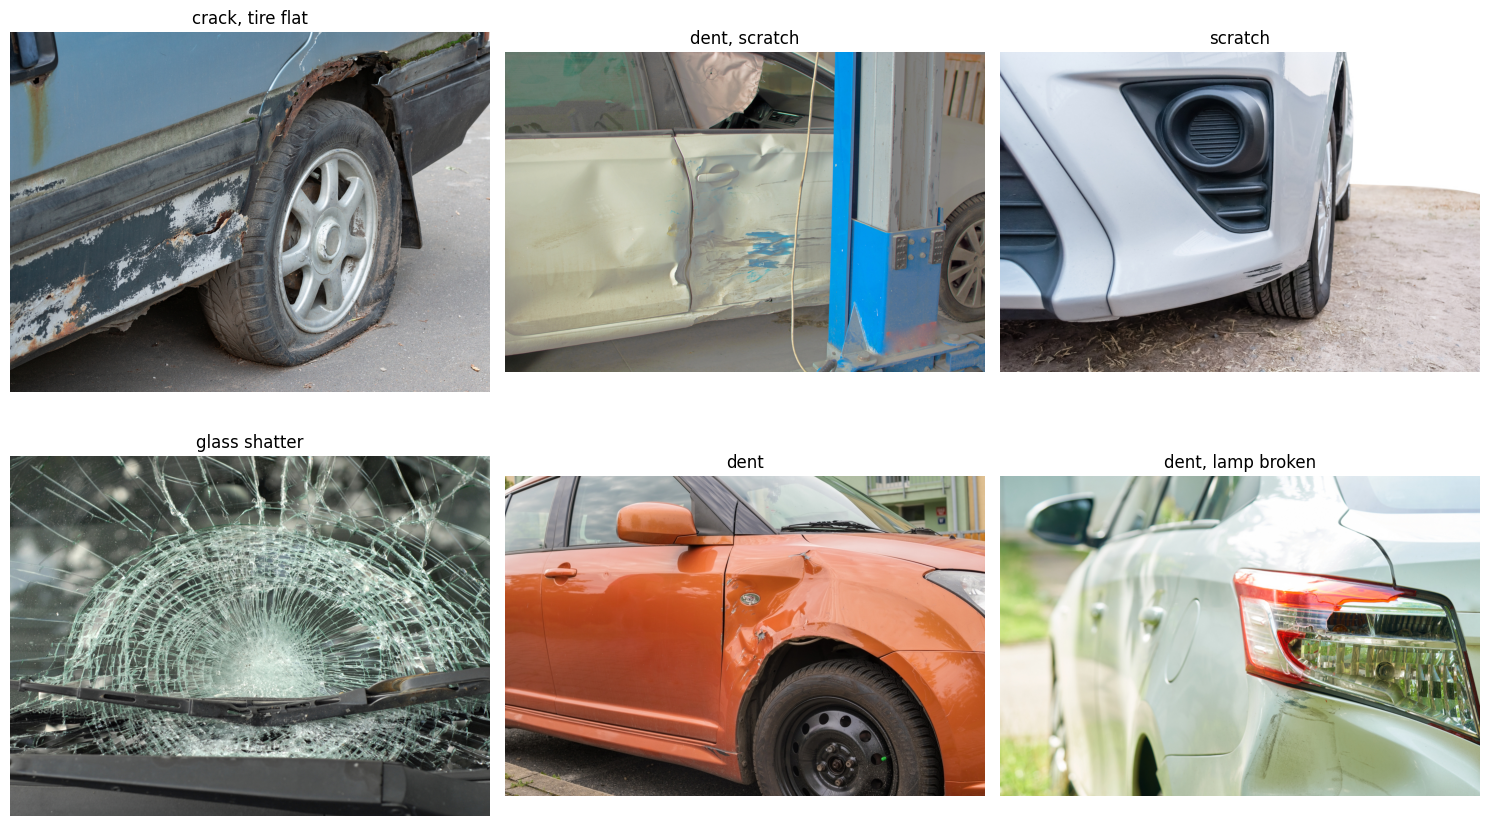

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

sample_images = random.sample(
    train_annotations["images"],
    6
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for axis, image_info_item in zip(axes.ravel(), sample_images):

    image_path = os.path.join(
        train_path,
        image_info_item["file_name"]
    )

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_annotations = [
        annotation
        for annotation in train_annotations["annotations"]
        if annotation["image_id"] == image_info_item["id"]
    ]

    damage_names = [
        category_names[annotation["category_id"]]
        for annotation in image_annotations
    ]

    axis.imshow(image)
    axis.set_title(
        ", ".join(sorted(set(damage_names)))
    )
    axis.axis("off")

plt.tight_layout()
plt.show()

## 4. Prepare Image Paths and Damage Labels


In [14]:
category_names = {
    1: "dent",
    2: "scratch",
    3: "crack",
    4: "glass_shatter",
    5: "lamp_broken",
    6: "tire_flat"
}

category_columns = list(category_names.values())

image_labels = {}

for image in train_annotations["images"]:
    image_labels[image["id"]] = {
        "file_name": image["file_name"],
        "labels": set()
    }

for annotation in train_annotations["annotations"]:
    image_id = annotation["image_id"]
    category_id = annotation["category_id"]

    image_labels[image_id]["labels"].add(
        category_names[category_id]
    )

In [15]:
def prepare_labels(annotations):
    image_labels = {}

    for image in annotations["images"]:
        image_labels[image["id"]] = {
            "file_name": image["file_name"],
            "labels": set()
        }

    for annotation in annotations["annotations"]:
        image_id = annotation["image_id"]
        category_id = annotation["category_id"]

        image_labels[image_id]["labels"].add(
            category_names[category_id]
        )

    data = []

    for image_id, image_info_item in image_labels.items():

        row = {
            "file_name": image_info_item["file_name"]
        }

        for category in category_columns:
            row[category] = int(
                category in image_info_item["labels"]
            )

        data.append(row)

    return pd.DataFrame(data)

In [16]:
train_data = []

for image_id, image_info_item in image_labels.items():

    row = {
        "file_name": image_info_item["file_name"]
    }

    for category in category_columns:
        row[category] = int(
            category in image_info_item["labels"]
        )

    train_data.append(row)

train_data = prepare_labels(train_annotations)

print("Training dataset shape:", train_data.shape)

display(train_data.head())

Training dataset shape: (2816, 7)


,file_name,dent,scratch,crack,glass_shatter,lamp_broken,tire_flat
0,000001.jpg,0,1,0,0,0,1
1,000002.jpg,0,0,0,0,0,1
2,000003.jpg,0,0,0,0,0,1
3,000004.jpg,0,0,0,0,0,1
4,000005.jpg,0,0,0,0,0,1


In [17]:
print("Training dataset shape:", train_data.shape)

print("\nColumns:")
print(train_data.columns.tolist())

print("\nFirst five rows:")
display(train_data.head())

print("\nLabel counts:")
display(train_data[category_columns].sum())

Training dataset shape: (2816, 7)

Columns:
['file_name', 'dent', 'scratch', 'crack', 'glass_shatter', 'lamp_broken', 'tire_flat']

First five rows:


,file_name,dent,scratch,crack,glass_shatter,lamp_broken,tire_flat
0,000001.jpg,0,1,0,0,0,1
1,000002.jpg,0,0,0,0,0,1
2,000003.jpg,0,0,0,0,0,1
3,000004.jpg,0,0,0,0,0,1
4,000005.jpg,0,0,0,0,0,1



Label counts:


,0
dent,1242
scratch,1507
crack,434
glass_shatter,469
lamp_broken,489
tire_flat,219


## 5. Train/Test Split

The CarDD dataset provides predefined training, validation, and test splits. These official splits are preserved for model development and final evaluation.

The training set is used to train the models, the validation set is used for model comparison and hyperparameter tuning, and the test set is reserved for final evaluation.

In [18]:
val_annotation_path = os.path.join(
    annotations_path,
    "instances_val2017.json"
)

test_annotation_path = os.path.join(
    annotations_path,
    "instances_test2017.json"
)

with open(val_annotation_path, "r") as file:
    val_annotations = json.load(file)

with open(test_annotation_path, "r") as file:
    test_annotations = json.load(file)

print("Training images:", len(train_annotations["images"]))
print("Validation images:", len(val_annotations["images"]))
print("Test images:", len(test_annotations["images"]))

Training images: 2816
Validation images: 810
Test images: 374


In [19]:
val_data = prepare_labels(val_annotations)
test_data = prepare_labels(test_annotations)

print("Training dataset shape:", train_data.shape)
print("Validation dataset shape:", val_data.shape)
print("Test dataset shape:", test_data.shape)

Training dataset shape: (2816, 7)
Validation dataset shape: (810, 7)
Test dataset shape: (374, 7)


## 6. Image Preprocessing using OpenCV

Images are converted to grayscale, resized to a consistent resolution, smoothed using a Gaussian filter, and normalized before handcrafted feature extraction.

In [50]:
def preprocess_image(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(
            f"Unable to read image: {image_path}"
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    image = cv2.resize(
        image,
        image_size
    )

    image = cv2.GaussianBlur(
        image,
        (3, 3),
        0
    )

    image = image.astype(np.float32) / 255.0

    return image

## 7. Feature Extraction

Two complementary handcrafted computer-vision descriptors are used:

- **HOG (Histogram of Oriented Gradients):** captures edge and shape structure.
- **LBP (Local Binary Pattern):** captures local texture information.

The descriptors are concatenated into one feature vector for each image.

In [51]:
def extract_features(image_path):
    image = preprocess_image(image_path)

    hog_features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    lbp = local_binary_pattern(
        (image * 255).astype(np.uint8),
        P=8,
        R=1,
        method="uniform"
    )

    lbp_histogram, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(11),
        range=(0, 10),
        density=True
    )

    features = np.concatenate([
        hog_features,
        lbp_histogram
    ])

    return features


def extract_dataset_features(data, image_path):
    features = []

    for file_name in data["file_name"]:
        image_path_item = os.path.join(
            image_path,
            file_name
        )

        features.append(
            extract_features(image_path_item)
        )

    return np.array(features)


train_features = extract_dataset_features(
    train_data,
    train_path
)

val_features = extract_dataset_features(
    val_data,
    val_path
)

test_features = extract_dataset_features(
    test_data,
    test_path
)

print("Training features:", train_features.shape)
print("Validation features:", val_features.shape)
print("Test features:", test_features.shape)

Training features: (2816, 8110)
Validation features: (810, 8110)
Test features: (374, 8110)


## 8. Prepare Feature Matrix


In [52]:
train_x = train_features
val_x = val_features
test_x = test_features

train_y = train_data[category_columns].values
val_y = val_data[category_columns].values
test_y = test_data[category_columns].values

print("train_x:", train_x.shape)
print("val_x:", val_x.shape)
print("test_x:", test_x.shape)

print("train_y:", train_y.shape)
print("val_y:", val_y.shape)
print("test_y:", test_y.shape)

train_x: (2816, 8110)
val_x: (810, 8110)
test_x: (374, 8110)
train_y: (2816, 6)
val_y: (810, 6)
test_y: (374, 6)


## 9. Feature Standardization

`StandardScaler` is fitted only on the training features. The fitted scaler is then used to transform validation and test features to prevent data leakage.

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

train_x_scaled = scaler.fit_transform(train_x)
val_x_scaled = scaler.transform(val_x)
test_x_scaled = scaler.transform(test_x)

print("Training scaled features:", train_x_scaled.shape)
print("Validation scaled features:", val_x_scaled.shape)
print("Test scaled features:", test_x_scaled.shape)

Training scaled features: (2816, 8110)
Validation scaled features: (810, 8110)
Test scaled features: (374, 8110)


## 10. PCA Dimensionality Reduction

PCA is fitted only on the standardized training features. The number of components is selected automatically to retain 95% of the variance.

In [54]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=0.95,
    svd_solver="full"
)

train_x_pca = pca.fit_transform(
    train_x_scaled
)

val_x_pca = pca.transform(
    val_x_scaled
)

test_x_pca = pca.transform(
    test_x_scaled
)

print("Original features:", train_x.shape[1])
print("PCA components:", pca.n_components_)
print("Explained variance:", pca.explained_variance_ratio_.sum())

print("Training PCA features:", train_x_pca.shape)
print("Validation PCA features:", val_x_pca.shape)
print("Test PCA features:", test_x_pca.shape)

Original features: 8110
PCA components: 1335
Explained variance: 0.9500878386281809
Training PCA features: (2816, 1335)
Validation PCA features: (810, 1335)
Test PCA features: (374, 1335)


## 11. Linear Support Vector Machine

A Linear Support Vector Machine (SVM) is used for multi-label damage classification.

A One-vs-Rest strategy trains an independent binary classifier for each damage category, allowing an image to be assigned multiple damage labels simultaneously.

In [55]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC

model = OneVsRestClassifier(
    LinearSVC(
        class_weight="balanced",
        dual=False,
        tol=1e-2,
        max_iter=1000,
        random_state=42
    ),
    n_jobs=-1
)

model.fit(
    train_x_pca,
    train_y
)

val_predictions = model.predict(
    val_x_pca
)

print("Validation predictions:", val_predictions.shape)

Validation predictions: (810, 6)


## 12. Model Evaluation

The multi-label classifier is evaluated using Hamming Loss, Micro Precision, Micro Recall, Micro F1-score, and Macro F1-score.

Micro-averaged metrics summarize performance across all label decisions, while Macro F1 gives equal importance to each damage category.

In [56]:
from sklearn.metrics import (
    hamming_loss,
    precision_score,
    recall_score,
    f1_score
)

hamming_loss_value = hamming_loss(
    val_y,
    val_predictions
)

micro_precision = precision_score(
    val_y,
    val_predictions,
    average="micro",
    zero_division=0
)

micro_recall = recall_score(
    val_y,
    val_predictions,
    average="micro",
    zero_division=0
)

micro_f1 = f1_score(
    val_y,
    val_predictions,
    average="micro",
    zero_division=0
)

macro_f1 = f1_score(
    val_y,
    val_predictions,
    average="macro",
    zero_division=0
)

print("Hamming Loss:", hamming_loss_value)
print("Micro Precision:", micro_precision)
print("Micro Recall:", micro_recall)
print("Micro F1-score:", micro_f1)
print("Macro F1-score:", macro_f1)

Hamming Loss: 0.257201646090535
Micro Precision: 0.49499615088529636
Micro Recall: 0.5198059822150364
Micro F1-score: 0.5070977917981072
Macro F1-score: 0.47611850740359035


## 13. Final Model Selection

Class imbalance is addressed using balanced class weights in the Linear SVM. The regularization parameter `C` is tuned using the validation set, with Micro F1-score used as the primary selection metric.

In [57]:
c_values = [0.01, 0.1, 1, 10]

best_c = None
best_micro_f1 = -1
best_model = None

for c_value in c_values:
    candidate_model = OneVsRestClassifier(
        LinearSVC(
            C=c_value,
            class_weight="balanced",
            dual=False,
            tol=1e-2,
            max_iter=1000,
            random_state=42
        ),
        n_jobs=-1
    )

    candidate_model.fit(
        train_x_pca,
        train_y
    )

    candidate_predictions = candidate_model.predict(
        val_x_pca
    )

    candidate_micro_f1 = f1_score(
        val_y,
        candidate_predictions,
        average="micro",
        zero_division=0
    )

    print(
        f"C={c_value} | "
        f"Validation Micro F1={candidate_micro_f1:.4f}"
    )

    if candidate_micro_f1 > best_micro_f1:
        best_micro_f1 = candidate_micro_f1
        best_c = c_value
        best_model = candidate_model

print("\nBest C:", best_c)
print("Best Validation Micro F1:", best_micro_f1)

C=0.01 | Validation Micro F1=0.5147
C=0.1 | Validation Micro F1=0.5086
C=1 | Validation Micro F1=0.5071
C=10 | Validation Micro F1=0.5083

Best C: 0.01
Best Validation Micro F1: 0.5147286821705427


## 14. Final Model Evaluation

The final Linear SVM model is evaluated using the selected hyperparameter configuration. Overall multi-label performance is measured using Hamming Loss, Micro Precision, Micro Recall, Micro F1-score, and Macro F1-score.

In [58]:
final_model = best_model

final_val_predictions = final_model.predict(
    val_x_pca
)

final_hamming_loss = hamming_loss(
    val_y,
    final_val_predictions
)

final_micro_precision = precision_score(
    val_y,
    final_val_predictions,
    average="micro",
    zero_division=0
)

final_micro_recall = recall_score(
    val_y,
    final_val_predictions,
    average="micro",
    zero_division=0
)

final_micro_f1 = f1_score(
    val_y,
    final_val_predictions,
    average="micro",
    zero_division=0
)

final_macro_f1 = f1_score(
    val_y,
    final_val_predictions,
    average="macro",
    zero_division=0
)

print("Final Hamming Loss:", final_hamming_loss)
print("Final Micro Precision:", final_micro_precision)
print("Final Micro Recall:", final_micro_recall)
print("Final Micro F1-score:", final_micro_f1)
print("Final Macro F1-score:", final_macro_f1)

Final Hamming Loss: 0.25761316872427986
Final Micro Precision: 0.49441548771407295
Final Micro Recall: 0.5367825383993533
Final Micro F1-score: 0.5147286821705427
Final Macro F1-score: 0.4834797531468997


## 15. Final Test Evaluation

The locked final model is evaluated on the unseen test set. The test set is used only once for the final assessment of model generalization.

In [59]:
test_predictions = final_model.predict(
    test_x_pca
)

test_hamming_loss = hamming_loss(
    test_y,
    test_predictions
)

test_micro_precision = precision_score(
    test_y,
    test_predictions,
    average="micro",
    zero_division=0
)

test_micro_recall = recall_score(
    test_y,
    test_predictions,
    average="micro",
    zero_division=0
)

test_micro_f1 = f1_score(
    test_y,
    test_predictions,
    average="micro",
    zero_division=0
)

test_macro_f1 = f1_score(
    test_y,
    test_predictions,
    average="macro",
    zero_division=0
)

print("Test Hamming Loss:", test_hamming_loss)
print("Test Micro Precision:", test_micro_precision)
print("Test Micro Recall:", test_micro_recall)
print("Test Micro F1-score:", test_micro_f1)
print("Test Macro F1-score:", test_macro_f1)

Test Hamming Loss: 0.28342245989304815
Test Micro Precision: 0.4410480349344978
Test Micro Recall: 0.5459459459459459
Test Micro F1-score: 0.48792270531400966
Test Macro F1-score: 0.4548509339415847


## 16. Damage Extent Analysis

The segmentation annotations are used to estimate the visible extent of damage in each image.

For each damage instance, the annotated area is divided by the image area to obtain a damage-area ratio.

In [60]:
def calculate_damage_extent(annotations, image_path):
    image_dimensions = {
        image["id"]: (
            image["width"],
            image["height"]
        )
        for image in annotations["images"]
    }

    extent_data = []

    for annotation in annotations["annotations"]:
        image_id = annotation["image_id"]
        category_id = annotation["category_id"]

        width, height = image_dimensions[image_id]

        image_area = width * height
        damage_area_ratio = annotation["area"] / image_area

        extent_data.append({
            "image_id": image_id,
            "file_name": next(
                image["file_name"]
                for image in annotations["images"]
                if image["id"] == image_id
            ),
            "category": category_names[category_id],
            "damage_area": annotation["area"],
            "image_area": image_area,
            "damage_area_ratio": damage_area_ratio
        })

    return pd.DataFrame(extent_data)


train_extent = calculate_damage_extent(
    train_annotations,
    train_path
)

print("Damage extent records:", train_extent.shape)
train_extent.head()

Damage extent records: (6211, 6)


,image_id,file_name,category,damage_area,image_area,damage_area_ratio
0,1,000001.jpg,scratch,13584.0,750000,0.018112
1,1,000001.jpg,tire_flat,298742.0,750000,0.398323
2,2,000002.jpg,tire_flat,114126.0,667000,0.171103
3,3,000003.jpg,tire_flat,299792.0,667000,0.449463
4,4,000004.jpg,tire_flat,383763.0,667000,0.575357


## 17. Damage Severity Estimation

Visible damage severity is estimated from the distribution of damage-area ratios in the training data.

The 33rd and 67th percentiles are used to define minor, moderate, and severe visible damage extent.

In [61]:
minor_threshold = train_extent["damage_area_ratio"].quantile(0.33)
severe_threshold = train_extent["damage_area_ratio"].quantile(0.67)

def assign_severity(area_ratio):
    if area_ratio <= minor_threshold:
        return "minor"
    if area_ratio <= severe_threshold:
        return "moderate"
    return "severe"


train_extent["severity"] = train_extent[
    "damage_area_ratio"
].apply(assign_severity)

print("Minor threshold:", minor_threshold)
print("Severe threshold:", severe_threshold)

print("\nSeverity distribution:")
print(
    train_extent["severity"].value_counts()
)

Minor threshold: 0.01803921971345156
Severe threshold: 0.09079131954022988

Severity distribution:
severity
moderate    2111
severe      2050
minor       2050
Name: count, dtype: int64


## 18. Example Prediction

A test image is passed through the complete prediction pipeline to evaluate multi-label damage detection.

In [64]:
sample_index = 0

sample_image = test_data.iloc[sample_index]

sample_file_name = sample_image["file_name"]
sample_image_path = os.path.join(
    test_path,
    sample_file_name
)

sample_features = extract_features(
    sample_image_path
).reshape(1, -1)

sample_features_scaled = scaler.transform(
    sample_features
)

sample_features_pca = pca.transform(
    sample_features_scaled
)

sample_prediction = final_model.predict(
    sample_features_pca
)[0]

detected_categories = [
    category_columns[index]
    for index, value in enumerate(sample_prediction)
    if value == 1
]

print("Image:", sample_file_name)
print("Detected damage:", detected_categories)

Image: 000012.jpg
Detected damage: ['scratch', 'crack', 'lamp_broken']


## 19. Save Model Artifact for Deployment

The fitted preprocessing and classification components are combined into a single scikit-learn pipeline and saved as one model artifact for Streamlit deployment.

In [72]:
import joblib
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", scaler),
    ("pca", pca),
    ("classifier", final_model)
])

model_artifact = {
    "pipeline": pipeline,
    "category_columns": category_columns
}

joblib.dump(
    model_artifact,
    "car_damage_model.pkl"
)

print("Model pipeline saved successfully.")

Model pipeline saved successfully.


In [73]:
from google.colab import files
files.download("car_damage_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 20. Reload Test

The saved model pipeline is reloaded and tested on the sample image to verify prediction reproducibility.

In [74]:
loaded_artifact = joblib.load(
    "car_damage_model.pkl"
)

loaded_pipeline = loaded_artifact["pipeline"]
loaded_category_columns = loaded_artifact["category_columns"]

reloaded_prediction = loaded_pipeline.predict(
    sample_features
)[0]

reloaded_categories = [
    loaded_category_columns[index]
    for index, value in enumerate(reloaded_prediction)
    if value == 1
]

print("Original prediction:", detected_categories)
print("Reloaded prediction:", reloaded_categories)

print(
    "Predictions match:",
    detected_categories == reloaded_categories
)

Original prediction: ['scratch', 'crack', 'lamp_broken']
Reloaded prediction: ['scratch', 'crack', 'lamp_broken']
Predictions match: True


## 21. Conclusion

This project developed a classical computer-vision and machine-learning pipeline for multi-label car damage assessment and detection.

The system uses OpenCV for image preprocessing, HOG and LBP for handcrafted feature extraction, StandardScaler for feature standardization, PCA for dimensionality reduction, and a One-vs-Rest Linear SVM for multi-label damage classification.

The final model achieved a validation Micro F1-score of 0.515 and a test Micro F1-score of 0.488. The model was also saved and reloaded successfully as `car_damage_model.pkl` for Streamlit web application deployment.


## References

1. CarDD Dataset: https://cardd-ustc.github.io/
2. scikit-learn Documentation: https://scikit-learn.org/
3. OpenCV Documentation: https://docs.opencv.org/
4. scikit-image Documentation: https://scikit-image.org/